# Stan Comparison For Gaussian K=3 Rolling-Standardized HMM

This notebook runs a 3-state Gaussian HMM in Stan on the rolling-standardized crypto returns. It uses the same CmdStan workflow from pset 5 and the same Stan model file as the 2-state notebook, but changes the data and reporting for `K = 3`.

The goal is to see whether the standardized Gaussian model can support three interpretable regimes without collapsing the way the original 3-state Student-t model did.

## What this notebook tests

- Whether a third Gaussian regime is actually used on rolling-standardized returns.
- Whether Stan still mixes acceptably at `K = 3`.
- Whether the inferred regimes look like low-vol, medium-vol, and stress states rather than one dominant state plus two weak leftovers.

## Important note

The Stan model uses diagonal Gaussian state covariances with ordered volatility levels. That keeps the model much more identifiable than the old full-covariance heavy-tailed setup, and is exactly why this is a good next diagnostic experiment.

In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel, cmdstan_path
from IPython.display import display

In [22]:
# troubleshooting since I couldn't figure out how to get Stan to work without forcing hierarchical_py manually

import sys
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

env_prefix = Path(sys.executable).resolve().parents[1]
cmdstan_dir = env_prefix / "bin" / "cmdstan"

print("python:", sys.executable)
print("trying cmdstan at:", cmdstan_dir)

set_cmdstan_path(str(cmdstan_dir))
print("cmdstan_path():", cmdstan_path())

from cmdstanpy import CmdStanModel
model = CmdStanModel(stan_file="hierarchical_py.stan")

python: /opt/anaconda3/envs/stat221-ps5/bin/python
trying cmdstan at: /opt/anaconda3/envs/stat221-ps5/bin/cmdstan
cmdstan_path(): /opt/anaconda3/envs/stat221-ps5/bin/cmdstan


## CmdStan environment helpers from pset 5

These are the same local macOS helpers used in the earlier Stan notebook.

In [24]:
def detect_macos_sdkroot() -> str | None:
    xcrun = shutil.which('xcrun')
    if xcrun is not None:
        try:
            result = subprocess.run([xcrun, '--show-sdk-path'], check=True, capture_output=True, text=True)
            sdkroot = Path(result.stdout.strip())
            if sdkroot.exists():
                return str(sdkroot)
        except (OSError, subprocess.SubprocessError):
            pass

    candidate_roots = [
        Path('/Library/Developer/CommandLineTools/SDKs'),
        Path('/Applications/Xcode.app/Contents/Developer/Platforms/MacOSX.platform/Developer/SDKs'),
    ]
    for root in candidate_roots:
        if not root.exists():
            continue
        candidates = sorted(root.glob('MacOSX*.sdk'), reverse=True)
        if candidates:
            return str(candidates[0])
    return None


def find_cmdstan_home() -> Path | None:
    env_cmdstan = os.environ.get('CMDSTAN')
    if env_cmdstan:
        path = Path(env_cmdstan).expanduser()
        if path.exists():
            return path

    try:
        path = Path(cmdstan_path())
        if path.exists():
            return path
    except Exception:
        pass

    cmdstan_root = Path.home() / '.cmdstan'
    if not cmdstan_root.exists():
        return None

    candidates = sorted([path for path in cmdstan_root.glob('cmdstan-*') if path.is_dir()], key=lambda path: path.name, reverse=True)
    return candidates[0] if candidates else None


def configure_cmdstan_environment() -> None:
    env_bin = Path(sys.executable).resolve().parent
    current_path = os.environ.get('PATH', '')
    path_entries = current_path.split(os.pathsep) if current_path else []
    if str(env_bin) not in path_entries:
        os.environ['PATH'] = f"{env_bin}{os.pathsep}{current_path}" if current_path else str(env_bin)

    make_path = shutil.which('make')
    if make_path is not None:
        os.environ.setdefault('MAKE', make_path)

    sdkroot = detect_macos_sdkroot()
    if sdkroot is not None:
        os.environ.setdefault('SDKROOT', sdkroot)
        os.environ.setdefault('CONDA_BUILD_SYSROOT', sdkroot)

    cmdstan_home = find_cmdstan_home()
    if cmdstan_home is not None:
        os.environ.setdefault('CMDSTAN', str(cmdstan_home))


configure_cmdstan_environment()
print('python:', sys.executable)
print('CMDSTAN:', os.environ.get('CMDSTAN', '<not found>'))

python: /opt/anaconda3/envs/stat221-ps5/bin/python
CMDSTAN: /opt/anaconda3/envs/stat221-ps5/bin/cmdstan


## Load and preprocess the returns

This mirrors the healthier preprocessing choice: 30-day rolling standardization of the daily log returns.

In [27]:
PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / 'crypto_stage1_processed'
STAN_FILE = PROJECT_DIR / 'gaussian_k2_rollstd_hmm.stan'
OUT_DIR = DATA_DIR / 'stan_k3_rollstd_comparison'
OUT_DIR.mkdir(parents=True, exist_ok=True)


def resolve_table_path(base_path) -> Path:
    base = Path(base_path)
    candidates = [base] if base.suffix in {'.parquet', '.pkl'} else [base.with_suffix('.parquet'), base.with_suffix('.pkl')]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'No saved table found for {base}')


def read_table(base_path) -> pd.DataFrame:
    path = resolve_table_path(base_path)
    if path.suffix == '.parquet':
        return pd.read_parquet(path)
    if path.suffix == '.pkl':
        return pd.read_pickle(path)
    raise ValueError(f'Unsupported table suffix: {path.suffix}')


returns = read_table(DATA_DIR / 'returns_daily').copy()
RET_COLS = [c for c in returns.columns if c.endswith('_ret')]
ROLL_WINDOW = 30
roll_mean = returns[RET_COLS].rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).mean()
roll_std = returns[RET_COLS].rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).std()
returns_rollstd = returns[['date']].copy()
returns_rollstd[RET_COLS] = (returns[RET_COLS] - roll_mean) / roll_std
returns_rollstd = returns_rollstd.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

Y = returns_rollstd[RET_COLS].to_numpy(dtype=float)
dates = pd.to_datetime(returns_rollstd['date']).reset_index(drop=True)
T, d = Y.shape
K = 3

print('Stan data shape:', Y.shape)
display(returns_rollstd.head())

Stan data shape: (1994, 5)


,date,BTC_ret,ETH_ret,SOL_ret,BNB_ret,AVAX_ret
0,2020-10-22 00:00:00+00:00,0.399121,1.708647,0.830119,0.641052,0.923310
1,2020-10-23 00:00:00+00:00,-0.623360,-0.728717,0.217990,-0.304456,-0.335798
2,2020-10-24 00:00:00+00:00,0.473779,0.078759,-0.118305,-0.216738,-0.254969
3,2020-10-25 00:00:00+00:00,-0.781368,-0.852888,-0.825982,-0.796929,-0.070919
4,2020-10-26 00:00:00+00:00,-0.285961,-1.499867,-0.778629,0.836527,0.052243


## Stan data and run settings

The 3-state model is harder than the 2-state one, so this notebook uses a modestly larger NUTS budget. It is still meant to be practical rather than heroic.

In [30]:
stan_data = {
    'T': int(T),
    'd': int(d),
    'K': int(K),
    'Y': Y,
    'mu_prior_scale': np.repeat(0.5, d),
    'trans_conc': 5.0,
    'log_sigma_sd': 0.45,
    'z_sigma_sd': 0.20,
}

STAN_CHAINS = 4
STAN_PARALLEL_CHAINS = 4
ITER_WARMUP = 500
ITER_SAMPLING = 500
ADAPT_DELTA = 0.92
MAX_TREEDEPTH = 12
REFRESH = 50

print({
    'K': K,
    'chains': STAN_CHAINS,
    'iter_warmup': ITER_WARMUP,
    'iter_sampling': ITER_SAMPLING,
    'adapt_delta': ADAPT_DELTA,
    'max_treedepth': MAX_TREEDEPTH,
})

{'K': 3, 'chains': 4, 'iter_warmup': 500, 'iter_sampling': 500, 'adapt_delta': 0.92, 'max_treedepth': 12}


## Compile and sample

This uses the same generic Stan model file as the 2-state notebook. The number of states comes from the data, not from editing the Stan file.

In [33]:
model = CmdStanModel(stan_file=str(STAN_FILE))
print('compiled:', STAN_FILE)

compiled: /Users/diego/Stat 221/gaussian_k2_rollstd_hmm.stan


In [35]:
fit = model.sample(
    data=stan_data,
    chains=STAN_CHAINS,
    parallel_chains=STAN_PARALLEL_CHAINS,
    iter_warmup=ITER_WARMUP,
    iter_sampling=ITER_SAMPLING,
    adapt_delta=ADAPT_DELTA,
    max_treedepth=MAX_TREEDEPTH,
    refresh=REFRESH,
    show_console=True,
)

fit.save_csvfiles(dir=str(OUT_DIR / 'csv'))
print('saved csv files to', OUT_DIR / 'csv')

16:06:53 - cmdstanpy - INFO - Chain [1] start processing
16:06:53 - cmdstanpy - INFO - Chain [2] start processing
16:06:53 - cmdstanpy - INFO - Chain [3] start processing
16:06:53 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 500
Chain [1] num_warmup = 500
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.92
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 12
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/8k/41v7gwyd5v19fw_03n7k8fym0000gn/T/tmpq9ygkiph/9ylgxb_7.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 94454
Cha

16:08:53 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 59.384 seconds (Warm-up)
Chain [2] 60.656 seconds (Sampling)
Chain [2] 120.04 seconds (Total)
Chain [2] 
Chain [2] 
Chain [3] Iteration: 900 / 1000 [ 90%]  (Sampling)
Chain [4] Iteration: 600 / 1000 [ 60%]  (Sampling)
Chain [3] Iteration: 950 / 1000 [ 95%]  (Sampling)


16:09:03 - cmdstanpy - INFO - Chain [3] done processing


...

Chain [4] Iteration: 1000 / 1000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 100.45 seconds (Warm-up)
Chain [4] 102.85 seconds (Sampling)
Chain [4] 203.3 seconds (Total)
Chain [4] 
Chain [4] 
Chain [1] Iteration: 900 / 1000 [ 90%]  (Sampling)
Chain [1] Iteration: 950 / 1000 [ 95%]  (Sampling)
Chain [1] Iteration: 1000 / 1000 [100%]  (Sampling)


16:10:42 - cmdstanpy - INFO - Chain [1] done processing
16:10:42 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gaussian_k2_rollstd_hmm.stan', line 69, column 10 to column 61)


Chain [1] 
Chain [1] Elapsed Time: 105.467 seconds (Warm-up)
Chain [1] 123.931 seconds (Sampling)
Chain [1] 229.398 seconds (Total)
Chain [1] 
Chain [1] 


16:10:43 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 4 had 4 divergent transitions (0.8%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


saved csv files to /Users/diego/Stat 221/crypto_stage1_processed/stan_k3_rollstd_comparison/csv


## Stan summary table

This is the standard CmdStan summary output. For `K = 3`, the first thing to look for is whether all three regimes show reasonable persistence and whether `R_hat` stays near 1.

In [37]:
stan_summary = fit.summary()
stan_summary.to_csv(OUT_DIR / 'stan_summary.csv')
display(stan_summary.head(60))

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-11541.200000,78.285400,111.113000,6.656870,-11612.300000,-11603.200000,-11345.300000,7.22616,1000.0000,0.021163,1.53727
"A[1,1]",0.399541,0.022175,0.036640,0.033766,0.349917,0.391912,0.467729,7.03057,1000.0000,0.020591,1.55212
"A[1,2]",0.439513,0.022550,0.037211,0.038235,0.373074,0.444808,0.495352,6.17129,1000.0000,0.018074,1.72359
"A[1,3]",0.160947,0.025549,0.038818,0.039423,0.105626,0.155108,0.229522,5.12464,1000.0000,0.015009,2.21499
"A[2,1]",0.417103,0.032811,0.050074,0.040699,0.324701,0.429481,0.482510,5.65644,1000.0000,0.016566,1.90236
"A[2,2]",0.441749,0.028031,0.044143,0.040558,0.361890,0.450727,0.502542,5.85749,1000.0000,0.017155,1.83426
"A[2,3]",0.141148,0.018069,0.028989,0.035552,0.100298,0.138646,0.187787,6.04785,1000.0000,0.017712,1.76954
"A[3,1]",0.329164,0.042682,0.065848,0.062784,0.245022,0.312066,0.447356,5.78295,1000.0000,0.016937,1.85213
"A[3,2]",0.322922,0.017256,0.037589,0.036886,0.256682,0.324844,0.380843,11.00780,1000.0000,0.032239,1.27551
"A[3,3]",0.347914,0.042362,0.066003,0.049727,0.225636,0.367967,0.429427,7.24550,1000.0000,0.021220,1.52679


## Interpretable posterior summaries

These summarize regime persistence, average volatility level, and a representative mean coordinate for each state.

In [39]:
A_draws = fit.stan_variable('A')
pi_draws = fit.stan_variable('pi')
mu_draws = fit.stan_variable('mu')
sigma_draws = fit.stan_variable('sigma')


def summarize_array(name, values):
    flat = np.asarray(values).reshape(-1)
    return {
        'variable': name,
        'mean': float(np.mean(flat)),
        'sd': float(np.std(flat, ddof=1)),
        'q05': float(np.quantile(flat, 0.05)),
        'median': float(np.quantile(flat, 0.50)),
        'q95': float(np.quantile(flat, 0.95)),
    }

rows = []
for k in range(K):
    rows.append(summarize_array(f'pi_{k}', pi_draws[:, k]))
    rows.append(summarize_array(f'A_{k}{k}', A_draws[:, k, k]))
    rows.append(summarize_array(f'mean_sigma_{k}', sigma_draws[:, k, :].mean(axis=1)))
    rows.append(summarize_array(f'mu_{k}_0', mu_draws[:, k, 0]))

stan_posterior_summary = pd.DataFrame(rows)
stan_posterior_summary.to_csv(OUT_DIR / 'stan_posterior_summary.csv', index=False)
display(stan_posterior_summary)

,variable,mean,sd,q05,median,q95
0,pi_0,0.394807,0.027093,0.361334,0.387336,0.447005
1,A_00,0.399541,0.036640,0.349917,0.391912,0.467729
2,mean_sigma_0,0.582950,0.117549,0.485955,0.527304,0.789928
3,mu_0_0,0.094461,0.560012,-0.487705,0.026667,0.815957
4,pi_1,0.419384,0.025681,0.374723,0.423925,0.456454
5,A_11,0.441749,0.044143,0.361890,0.450727,0.502542
6,mean_sigma_1,0.516821,0.045764,0.443856,0.531675,0.569472
7,mu_1_0,0.102630,0.414632,-0.477776,0.187890,0.528689
8,pi_2,0.185809,0.016638,0.160455,0.184229,0.214677
9,A_22,0.347914,0.066003,0.225636,0.367967,0.429427


## Posterior-mean smoothed state probabilities

Stan samples `gamma[t, k]` directly, so we can average those draws to get smoothed occupancy and most-likely-state shares.

In [41]:
gamma_draws = fit.stan_variable('gamma')
gamma_mean = gamma_draws.mean(axis=0)
ml_state = gamma_mean.argmax(axis=1)
state_share = np.bincount(ml_state, minlength=K) / len(ml_state)

stan_smoothed_df = pd.DataFrame({'date': dates})
for k in range(K):
    stan_smoothed_df[f'state_{k}_prob'] = gamma_mean[:, k]
stan_smoothed_df['ml_state'] = ml_state
stan_smoothed_df.to_pickle(OUT_DIR / 'stan_smoothed_state_probs.pkl')

print('Stan posterior-mean most-likely state shares:', state_share)
print('Stan posterior-mean average smoothed probabilities:', gamma_mean.mean(axis=0))

display(pd.DataFrame({
    'state': [f'state_{k}' for k in range(K)],
    'ml_share': state_share,
    'avg_smoothed_prob': gamma_mean.mean(axis=0),
}))

Stan posterior-mean most-likely state shares: [0.36960883 0.44784353 0.18254764]
Stan posterior-mean average smoothed probabilities: [0.39610843 0.42121907 0.1826725 ]


,state,ml_share,avg_smoothed_prob
0,state_0,0.369609,0.396108
1,state_1,0.447844,0.421219
2,state_2,0.182548,0.182672


## Visual readout

These plots answer the main practical question: do we really get three regimes, and do they separate meaningfully over time?

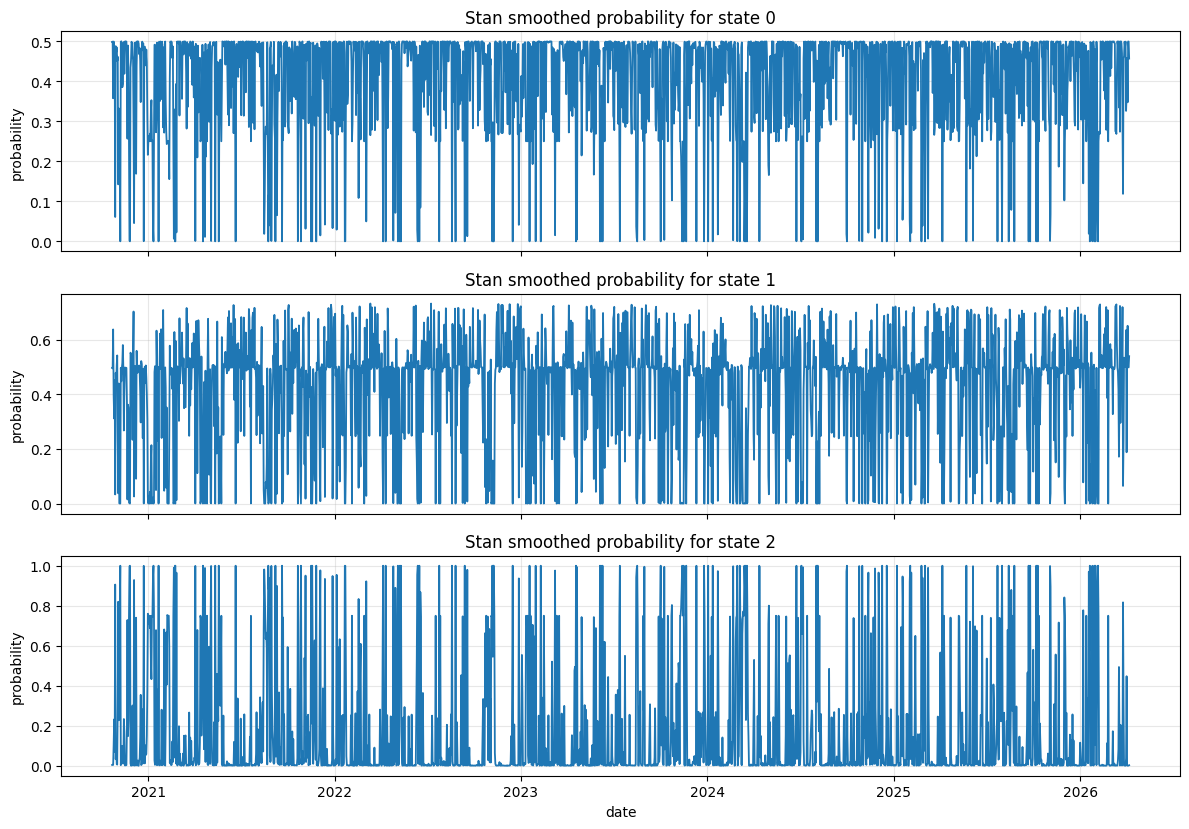

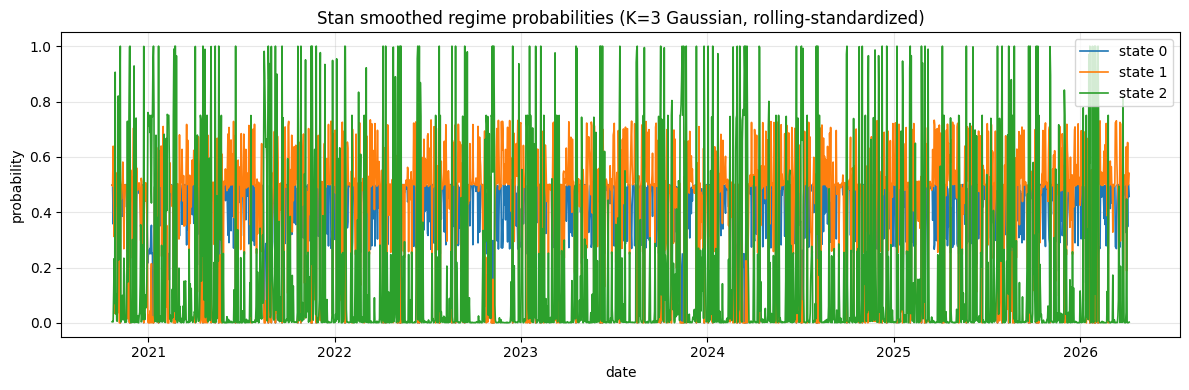

In [43]:
fig, axes = plt.subplots(K, 1, figsize=(12, 2.8 * K), sharex=True)
if K == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    ax.plot(pd.to_datetime(stan_smoothed_df['date']), stan_smoothed_df[f'state_{k}_prob'], lw=1.3)
    ax.set_title(f'Stan smoothed probability for state {k}')
    ax.set_ylabel('probability')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('date')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
for k in range(K):
    plt.plot(pd.to_datetime(stan_smoothed_df['date']), stan_smoothed_df[f'state_{k}_prob'], lw=1.2, label=f'state {k}')
plt.title('Stan smoothed regime probabilities (K=3 Gaussian, rolling-standardized)')
plt.xlabel('date')
plt.ylabel('probability')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Quick diagnostic flags

This cell surfaces the main warning signs for the 3-state fit: weak occupancy, poor `R_hat`, and low ESS.

In [45]:
summary_reset = stan_summary.reset_index().rename(columns={'index': 'parameter'})

rhat_bad = summary_reset[summary_reset['R_hat'] > 1.01].copy()
ess_bad = summary_reset[summary_reset['ESS_bulk'] < 100].copy()
weak_states = pd.DataFrame({
    'state': [f'state_{k}' for k in range(K)],
    'ml_share': state_share,
    'avg_smoothed_prob': gamma_mean.mean(axis=0),
})

print('Parameters with R_hat > 1.01')
display(rhat_bad[['parameter', 'R_hat', 'ESS_bulk', 'ESS_tail']].sort_values('R_hat', ascending=False).head(30))

print('Parameters with ESS_bulk < 100')
display(ess_bad[['parameter', 'ESS_bulk', 'ESS_tail', 'R_hat']].sort_values('ESS_bulk').head(30))

print('State occupancy summary')
display(weak_states)

Parameters with R_hat > 1.01


,parameter,R_hat,ESS_bulk,ESS_tail
5883,"gamma[1934,3]",4.68756,4.67590,1000.0
3306,"gamma[1075,3]",3.86110,4.66049,1000.0
3426,"gamma[1115,3]",2.45378,4.89303,1000.0
3281,"gamma[1067,2]",2.41756,4.92278,1000.0
4016,"gamma[1312,2]",2.41734,4.91427,1000.0
3280,"gamma[1067,1]",2.41731,4.92294,1000.0
4015,"gamma[1312,1]",2.41723,4.91445,1000.0
5030,"gamma[1650,2]",2.41691,4.91420,1000.0
5744,"gamma[1888,2]",2.41690,4.91913,1000.0
5029,"gamma[1650,1]",2.41688,4.91443,1000.0


Parameters with ESS_bulk < 100


,parameter,ESS_bulk,ESS_tail,R_hat
3306,"gamma[1075,3]",4.66049,1000.0,3.86110
5883,"gamma[1934,3]",4.67590,1000.0,4.68756
3426,"gamma[1115,3]",4.89303,1000.0,2.45378
1442,"gamma[454,2]",4.90946,1000.0,2.41497
1441,"gamma[454,1]",4.90992,1000.0,2.41478
3926,"gamma[1282,2]",4.91059,1000.0,2.41616
5509,"gamma[1810,1]",4.91066,1000.0,2.41185
3925,"gamma[1282,1]",4.91079,1000.0,2.41609
5510,"gamma[1810,2]",4.91084,1000.0,2.41185
1517,"gamma[479,2]",4.91119,1000.0,2.41442


State occupancy summary


,state,ml_share,avg_smoothed_prob
0,state_0,0.369609,0.396108
1,state_1,0.447844,0.421219
2,state_2,0.182548,0.182672


## How to interpret the result

A successful `K = 3` fit should show:
- all three states with nontrivial occupancy,
- reasonable persistence but not near-complete collapse,
- `R_hat` values near 1,
- and a visually interpretable low / medium / high volatility structure.

If one state still gets almost no occupancy, then the data may simply support two regimes better than three under this standardized Gaussian specification.